<a href="https://colab.research.google.com/github/d4vidi4n/EL7037/blob/main/CE_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
!pip install deap

import time
!pip install seaborn
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay



# Directorios

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# os.chdir(r"D:\Proyecto_CE")
os.chdir(r"/content/drive/MyDrive/Proyecto_CE")

In [5]:
os.listdir(r'LIB_SR_Desgaste/Data_ANSYS')

['crear_dataset_coef_25.ipynb', 'crear_dataset_coef_53.ipynb', 'df_ANSYS']

In [6]:
# Local
# damaged_data_path = r'LIB_SR_Desgaste\Data_ANSYS\df_ANSYS'
# no_damaged_data_path = r'DATA_ANSYS_no_damage'
# Alojado
damaged_data_path = r'LIB_SR_Desgaste/Data_ANSYS/df_ANSYS'
no_damaged_data_path = r'DATA_ANSYS_no_damage'

os.listdir(damaged_data_path)
os.listdir(no_damaged_data_path)

['entradas_1_102_celdas.csv',
 'entradas_1_25_celdas.csv',
 'entradas_1_74_celdas.csv',
 'entradas_1_53_celdas.csv']

# Importar datasets y filtrado total

In [7]:
def new_nan_verifier(datos):
  for i in range(len(datos)):
    for j in range(len(datos.keys())):
      if pd.isnull(datos.iloc[i,j]):
        print('Hay NaN en',i)
        break


def data_filter_of_NaNs(data):
    # Lista para guardar las filas que hay que borrar
    rows_to_drop = []

    # Ciclos par recorrer toda la dat y borrar aquellas filas con NaNs
    for simulation in range(len(data)):
        for variable in range(1, len(data.keys())):

            # Verificar si el valor es NaN
            if pd.isnull(data.iloc[simulation, variable]):
                rows_to_drop.append(simulation)
                break # El break se usa para salir del ciclo for variable y guardar solo un dato de la columna que se va a borrar

    # Borrado de las filas
    return data.drop(rows_to_drop)


def labeler_of_data_with_heat_data(data):
    # Datos de calor
    heat_data = data.filter(like='q')

    # Nombres de las columnas etiquetadas
    columns_idxs = np.linspace(1, len(heat_data.keys()), len(heat_data.keys())).astype(int)
    columns_idxs = [f"col_{i+1}" for i in range(len(heat_data.columns))]

    # Array con ceros para despues reemplazar con los labels
    base_dataframe_for_label_with_heat_data = pd.DataFrame( np.zeros( (len(heat_data),len(heat_data.keys())) ) , columns=columns_idxs)

    for simulation in range(len(heat_data)):
        damaged_cell_idx_column_list = [] # Ubicación de las celdas desgastadas en una simulación, pueden ser más de una
        for heat_value in range(len(heat_data.keys())-1):

            if heat_data.iloc[simulation, heat_value] > heat_data.iloc[simulation, heat_value+1]:
                damaged_cell_idx_column_list.append(1)

            else:
                damaged_cell_idx_column_list.append(0)
        damaged_cell_idx_column_list.append(0) # Se asigna el último 0 solo para que queden 7 elementos en la lista de ubicación de daño

        base_dataframe_for_label_with_heat_data.iloc[simulation] = np.array(damaged_cell_idx_column_list)

        # Mostrar todas las filas y los labels
        # print(simulation,' : ',damaged_cell_idx_column_list) # Se suma uno para que el valor de las celdas no dañadas sea 0

    # Concatenación de la data con los labels
    return pd.concat([data.reset_index(drop=True), base_dataframe_for_label_with_heat_data.reset_index(drop=True)], axis=1)


def filter_from_several_columns_to_one_column_label(data): # Esta función lo que hace es filtrar los datos que tienen más de una columna dañada eliminando aquellas que tienen más de una columna dañada
    # Lista para guardar las filas que hay que borrar
    rows_to_drop = []
    labels_data = data.filter(like='col_')

    # Ciclos par recorrer toda la data y borrar aquellas filas donde hay más de una columna con labels = 1
    for simulation in range(len(data)):
        if labels_data.iloc[simulation].sum() > 1 or labels_data.iloc[simulation].sum() == 0:
            rows_to_drop.append(simulation)

    # Borrado de las filas
    return data.drop(rows_to_drop)


def filter_from_binary_labels_to_column_idx(data):
    labels_data = data.filter(like='col_')
    damaged_cell_idx_column_list = []

    for simulation in range(len(labels_data)):
        fila = labels_data.iloc[simulation].to_numpy()      # convierte fila a array
        idx = np.where(fila == 1)[0]                      # posiciones donde hay 1

        if len(idx) > 0:
            damaged_cell_idx_column_list.append(idx[0]+1)  # toma la primera posición con 1
        else:
            damaged_cell_idx_column_list.append(0)    # o -1 si quieres marcar "sin daño"

    data['col_damaged'] = damaged_cell_idx_column_list
    return data


def binary_labeler(data):
  for i in range(len(data)):
    if data.iloc[i, -1] > 0:
      data.iloc[i, -1] = 1
  return data


def data_extractor_from_ansys_raw_data(path, csv_name):
    # Path y nombre del csv
    file_name = os.path.join(path, csv_name)

    # Extracción de los nombre de las columnas
    keys = pd.read_csv(file_name, sep=',', skipinitialspace=False, skiprows=3, skipfooter=0, engine='python')

    # Variables y sus unidades respectivas
    names_n_units_of_data = [name[5:] if keys.columns.get_loc(name)<10
                             else name[6:] for name in keys.keys()]
    # La data
    data = pd.read_csv(file_name, sep=',', skipinitialspace=False, header=6, skipfooter=0, names = names_n_units_of_data, engine='python')

    # Filtrado de NaNs
    data = data_filter_of_NaNs(data)

    # Generación de etiquetas
    data = labeler_of_data_with_heat_data(data)

    # Filtrado de datos a una única columna dañada
    data = filter_from_several_columns_to_one_column_label(data)

    # Transformación de labels [0, 1, 0, ... , 0] a ubicación de la columna
    data = filter_from_binary_labels_to_column_idx(data)

    # Generación de etiquetas binarias -> Desgaste o no -> posibles valores: {0, 1}
    # data = binary_labeler(data)

    return data


def labeler_for_no_damage_data(data):
  label_column = pd.DataFrame(np.zeros((len(data),1)).astype(int), columns=['col_damaged'])
  return pd.concat([data.reset_index(drop=True), label_column.reset_index(drop=True)], axis=1)


def data_extractor_from_ansys_raw_data_no_damage(path, csv_name):
    # Path y nombre del csv
    file_name = os.path.join(path, csv_name)

    # Extracción de los nombre de las columnas
    keys = pd.read_csv(file_name, sep=',', skipinitialspace=False, skiprows=3, skipfooter=0, engine='python')

    # Variables y sus unidades respectivas
    names_n_units_of_data = [name[5:] if keys.columns.get_loc(name)<10
                             else name[6:] for name in keys.keys()]
    # La data
    data = pd.read_csv(file_name, sep=',', skipinitialspace=False, header=6, skipfooter=0, names = names_n_units_of_data, engine='python')

    # Filtrado de NaNs
    data = data_filter_of_NaNs(data)

    # Generación de etiquetas -> Columna dañada -> posibles valores: {0, 2, 4, ...}
    data = labeler_for_no_damage_data(data)

    # Generación de etiquetas binarias -> Desgaste o no -> posibles valores: {0, 1}
    # data = binary_labeler(data)

    return data

In [8]:
def X_data_filter_by_variables(data, variables):

    # --- Limpiar nombres de columnas: eliminar unidades ---
    data.columns = data.columns.str.replace(r'\s+\[.*\]', '', regex=True)

    data_aux = []

    for variable in variables:
        # if para dejar las temperaturas en [°C]
        if variable[0] == 'T':
            data_aux.append(data.filter(like=variable) - 273.15)
        else:
            data_aux.append(data.filter(like=variable))

    data = data_aux[0]

    # Concatenación de la data con los labels
    for i in range(len(variables)-1):
        data = pd.concat([data, data_aux[i+1]], axis=1)

    # Se elimina la columna de Volumenpila porque no es necesaria
    variables = ['T_a', 'Vol']
    pattern = '|'.join(variables)

    try:
        data_filtered = data.filter(regex=pattern)
    except NameError:
        return data
    else:
        data.drop(columns=[*data_filtered.keys()], inplace=True)
        return data


def Y_data_filter(data, variable):
  return data.filter(like=variable)

# Importar datos

## Daño

In [9]:
# data_damage = data_extractor_from_ansys_raw_data(path=damaged_data_path, csv_name='out25_soh45_1.csv')
# data_damage = data_extractor_from_ansys_raw_data(path=damaged_data_path, csv_name='out25_soh82.csv')
data_damage = data_extractor_from_ansys_raw_data(path=damaged_data_path, csv_name='out53_soh82.csv')

In [10]:
data_damage

,,R,x1,y1,nx,ny,dx,dy,L,H,...,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_damaged
1,DP 1,9,25,14.400,8,4,36.0,28.800,302.0,115.200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,DP 2,9,25,15.600,8,4,37.0,31.200,309.0,124.800,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,DP 3,9,25,17.004,8,4,36.0,34.008,302.0,136.032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,DP 4,9,25,15.270,8,4,40.0,30.540,330.0,122.160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
5,DP 5,9,25,15.970,8,4,40.0,31.940,330.0,127.760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,DP 1246,9,25,17.400,8,4,50.0,34.800,400.0,139.200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14
1247,DP 1247,9,25,30.410,8,4,64.0,60.820,498.0,243.280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14
1248,DP 1248,9,25,25.850,8,4,60.0,51.700,470.0,206.800,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14
1249,DP 1249,9,25,29.500,8,4,62.0,59.000,484.0,236.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14


## Sin daño

In [11]:
# data_no_damage = data_extractor_from_ansys_raw_data_no_damage(path=no_damaged_data_path, csv_name='entradas_1_25_celdas.csv')
data_no_damage = data_extractor_from_ansys_raw_data_no_damage(path=no_damaged_data_path, csv_name='entradas_1_53_celdas.csv')

In [12]:
data_no_damage

,,K,Mesh Relevance,- celda1.x,- celda1.y,- volumen.x,- volumen.y,- H,- L,- Diametro,...,P07 [Pa],P08 [Pa],TC01 [K],TC02 [K],TC03 [K],TC04 [K],TC05 [K],TC06 [K],TC07 [K],col_damaged
0,DP 0,0.6,-50,30,25.25,4.75,148.9,148.9,442.678865,20.5,...,6.39407,-0.378904,286.900,286.900,286.900,286.900,286.900,286.900,286.900,0
1,DP 1,0.6,-50,30,25.25,4.75,148.9,148.9,442.678865,20.5,...,6.39407,-0.378904,286.911,286.914,286.916,286.918,286.920,286.922,286.925,0
2,DP 2,0.6,-50,30,25.25,4.75,148.9,148.9,442.678865,20.5,...,6.39407,-0.378904,286.946,286.954,286.963,286.972,286.981,286.988,286.999,0
3,DP 3,0.6,-50,30,25.25,4.75,148.9,148.9,442.678865,20.5,...,6.39407,-0.378904,287.003,287.022,287.042,287.061,287.083,287.099,287.122,0
4,DP 4,0.6,-50,30,25.25,4.75,148.9,148.9,442.678865,20.5,...,6.39407,-0.378904,287.082,287.116,287.153,287.186,287.226,287.254,287.294,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,DP 1245,1.2,-50,30,27.75,2.25,223.8,223.8,725.176352,25.5,...,36.46800,3.270330,302.543,302.928,303.298,303.801,304.184,304.370,305.221,0
1246,DP 1246,1.2,-50,30,27.75,2.25,223.8,223.8,725.176352,25.5,...,37.73430,3.238460,302.455,302.815,303.176,303.674,304.040,304.217,305.044,0
1247,DP 1247,1.2,-50,30,27.75,2.25,223.8,223.8,725.176352,25.5,...,39.07690,3.194260,302.395,302.717,303.062,303.551,303.903,304.072,304.881,0
1248,DP 1248,1.2,-50,30,27.75,2.25,223.8,223.8,725.176352,25.5,...,40.34360,3.115270,302.342,302.613,302.943,303.429,303.767,303.929,304.700,0


# Dataset en formato X,y con Tc, Tf

In [13]:
def features_calculator(datos):
  # display(datos)
  lista_de_features = []

  for variable in ['Tc']:#,'Tf','V']: #['Tc','Tf']: #

    lista_de_features.append(datos.filter(like=variable).keys())

  list_of_names = []
  deltas_list = []

  # Cálculos de temperaturas
  for group_of_features in lista_de_features: #Tc o Tf

    type_of_feature = group_of_features[0][:2] # F o C para signar el nombre de los deltas

    for i in range(len(group_of_features)-1): #Tc01, Tc02, Tc03, ...

      delta_name = 'delta_'+type_of_feature+'_'+str(i+1)
      # print(np.array(datos.iloc[:,:]).mean(axis=1).shape)
      deltas_array = (np.array(datos.iloc[:,i+1]) - np.array(datos.iloc[:,i]))/np.array(datos.iloc[:,:]).mean(axis=1)

      deltas_list.append(deltas_array)

      list_of_names.append(delta_name)

  datos = pd.DataFrame(np.stack(tuple(deltas_list), axis=1), columns=list_of_names)

  return datos

In [14]:
X1 = X_data_filter_by_variables(data_damage, ['Tc'])#,'Tf','Vf']) #['T', 'V']
y1 = Y_data_filter(data_damage, 'col_damaged')

X2 = X_data_filter_by_variables(data_no_damage, ['TC'])#,'TF','V'])
y2 = Y_data_filter(data_no_damage, 'col_damaged')

ansys_data_filtered_by_T = pd.concat([pd.DataFrame(X1.values, columns=X1.columns),
               pd.DataFrame(X2.values, columns=X1.columns)], axis=0, ignore_index=True)

y = pd.concat([y1, y2], axis=0, ignore_index=True)

X = features_calculator(ansys_data_filtered_by_T)

# display(X)
# display(y)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y, shuffle=True)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp, shuffle=True)

X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)
X_test, y_test = np.array(X_test), np.array(y_test)

## SVM

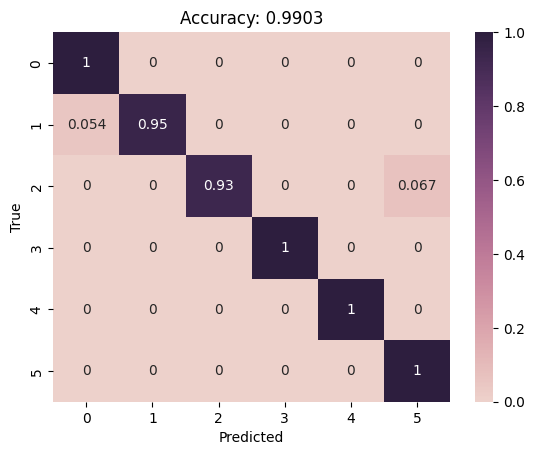

In [16]:
params_svc = {'C':[0.01, 0.1, 1, 10, 100], 'kernel':['linear', 'poly', 'rbf', 'sigmoid']}
clf = GridSearchCV(svm.SVC(), params_svc, cv=5) #ps es una variable global, no se coloca como entrada para reducir al máximo las entradas de la función y hacer menos confusa las iteraciones

# GridSearch
clf.fit(X_val, y_val.ravel())

best_clf = clf.best_estimator_ # Se extraen los mejores hiperparámetros calculados a través de GridSearchCV()

best_clf.fit(X_train, y_train.ravel())

y_pred = best_clf.predict(X_test)

sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
# plt.suptitle('Confusion matrix')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

Text(50.722222222222214, 0.5, 'True')

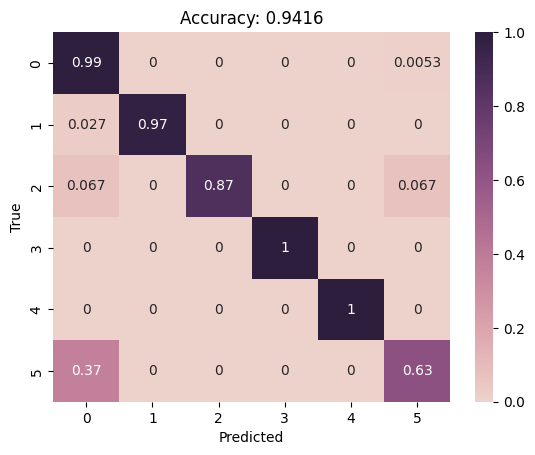

In [18]:
params_svc = {'C':[0.01, 0.1, 1, 10, 100], 'kernel':['linear', 'poly', 'rbf', 'sigmoid']}

parameters = {'n_estimators':[50, 100, 150, 200, 250]}
rf_clf = RandomForestClassifier(max_depth=8, random_state=42)

clf = GridSearchCV(rf_clf, parameters, cv=5) #ps es una variable global, no se coloca como entrada para reducir al máximo las entradas de la función y hacer menos confusa las iteraciones

# GridSearch
clf.fit(X_val, y_val.ravel())

best_clf = clf.best_estimator_ # Se extraen los mejores hiperparámetros calculados a través de GridSearchCV()

best_clf.fit(X_train, y_train.ravel())

y_pred = best_clf.predict(X_test)

sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
# plt.suptitle('Confusion matrix')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')

In [19]:
best_clf

RandomForestClassifier(max_depth=8, n_estimators=50, random_state=42)

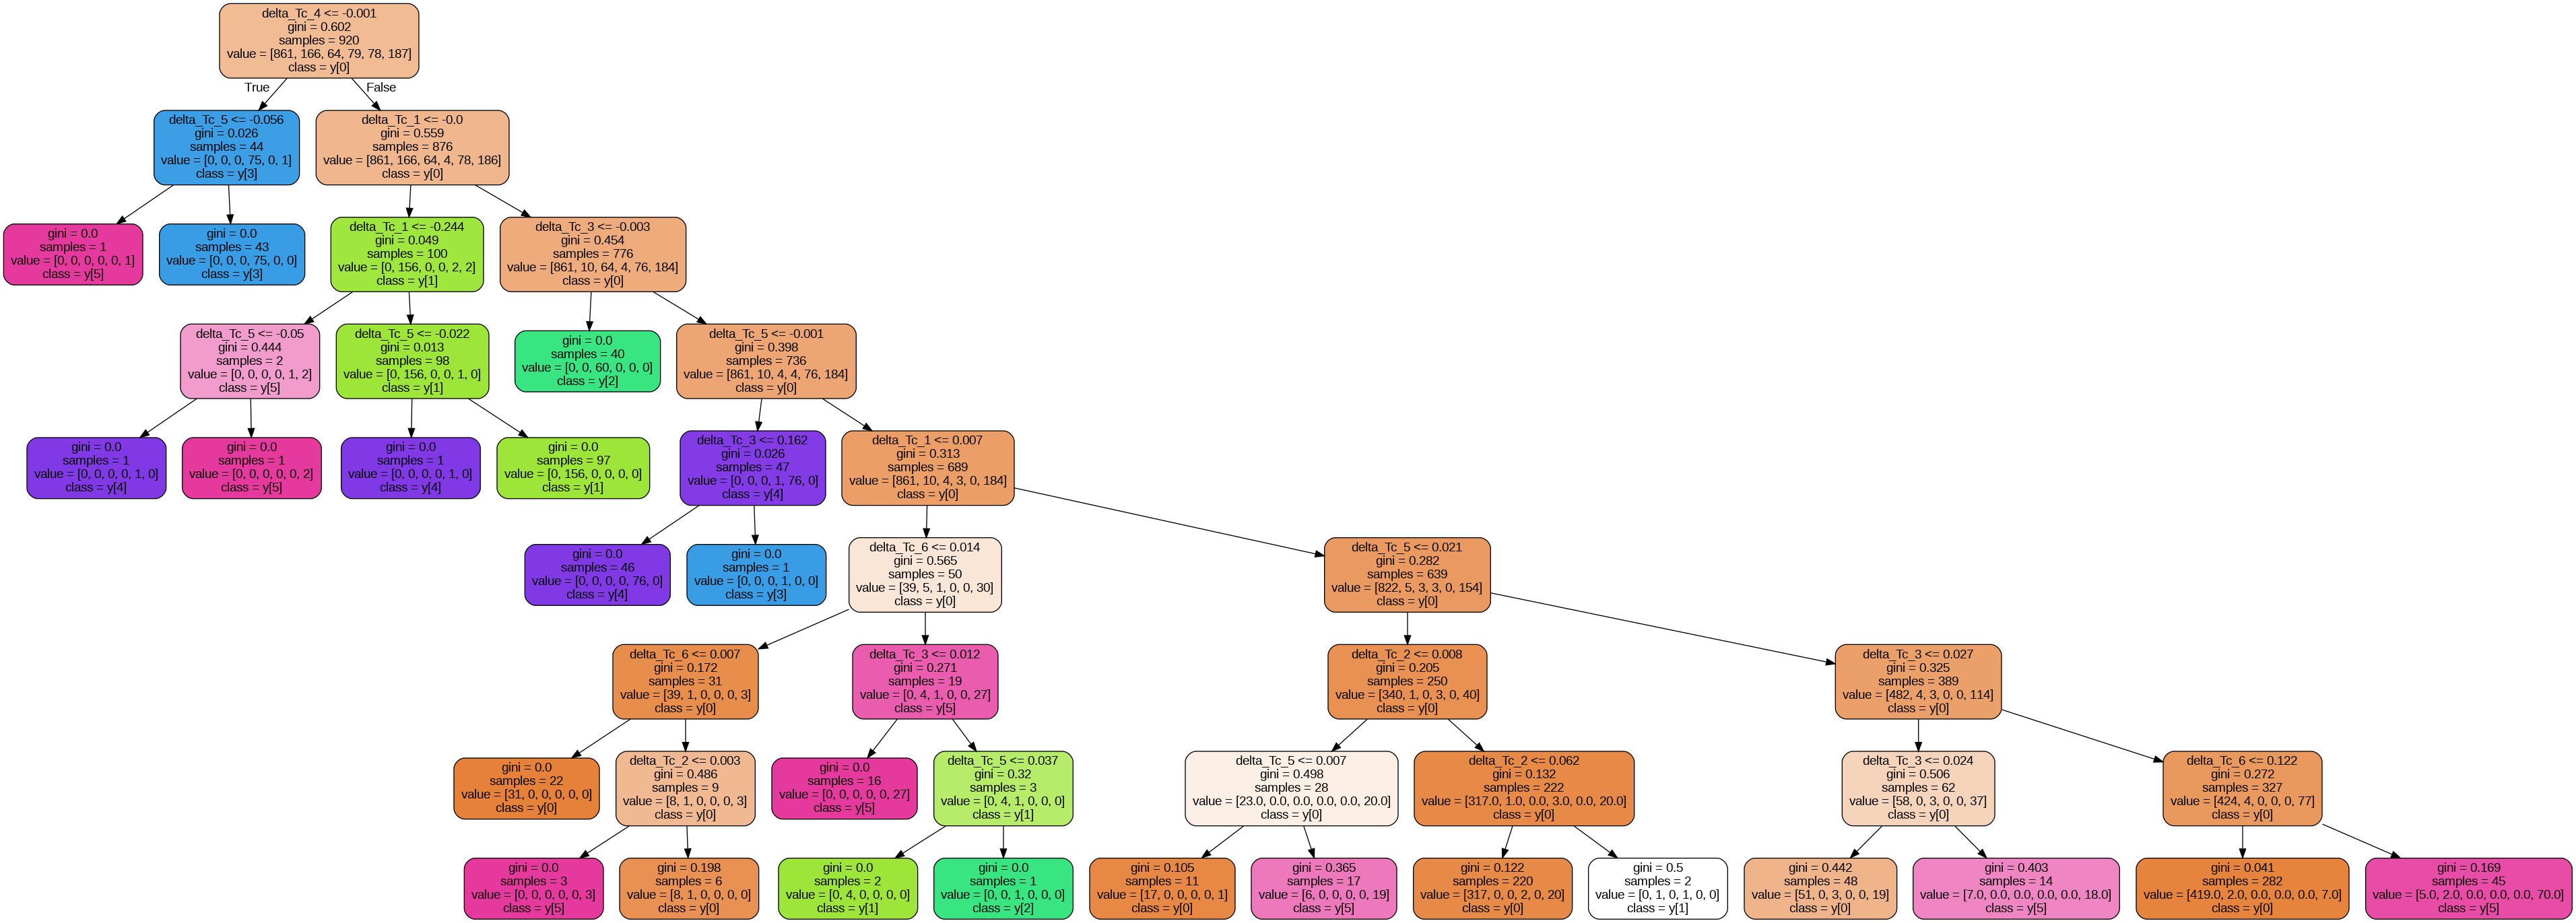

In [20]:
from sklearn.tree import export_graphviz
import graphviz
rf = best_clf
dot = export_graphviz(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=True,
    filled=True,
    rounded=True
)

# Convertir a imagen PNG
graph = graphviz.Source(dot)
graph.format = "png"
graph.render("arbol_random_forest")

from IPython.display import Image
Image(filename="arbol_random_forest.png")


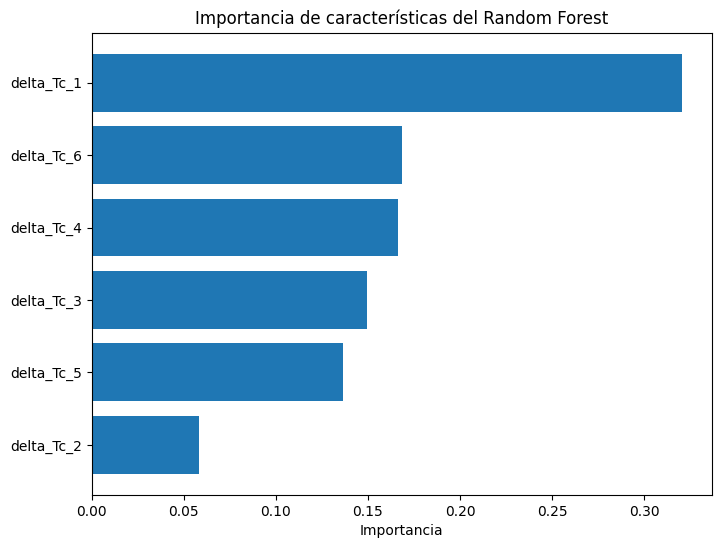

In [21]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.xlabel("Importancia")
plt.title("Importancia de características del Random Forest")
plt.show()


# Programación genética v1

In [ ]:
import operator
import random
import numpy as np
from deap import base, creator, tools, gp, algorithms
import matplotlib.pyplot as plt

In [ ]:
# Número de características de entrada
n_features = len(X.columns)

# Crear el conjunto de primitivas
pset = gp.PrimitiveSet("MAIN", n_features)

# Renombrar los argumentos con los nombres reales
pset.renameArguments(**{f"ARG{i}": name for i, name in enumerate(X.columns)})

# Operadores aritméticos seguros
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)

# División segura (para evitar división por 0)
def safeDiv(a, b):
    return a / b if b != 0 else 1
pset.addPrimitive(safeDiv, 2)

# --- Operaciones lógicas (booleanas) ---
# def if_then_else(condition, out1, out2):
#     return out1 if condition else out2

def safe_div(x, y):
    return x / y if abs(y) > 1e-6 else x

def logical_and(x, y):
    return 1.0 if (x > 0) and (y > 0) else 0.0

def logical_or(x, y):
    return 1.0 if (x > 0) or (y > 0) else 0.0

def logical_not(x):
    return 1.0 if x <= 0 else 0.0

# Agregamos las funciones lógicas
pset.addPrimitive(logical_and, 2)
pset.addPrimitive(logical_or, 2)
pset.addPrimitive(logical_not, 1)
# pset.addPrimitive(if_then_else, 3)

# Constantes aleatorias
pset.addEphemeralConstant("rand101", lambda: random.uniform(-100, 100))

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # queremos maximizar
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

In [ ]:
toolbox = base.Toolbox()

import operator
from deap import base, creator, tools, gp

# (Suponiendo que ya tienes definido pset, creator y toolbox)
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# === 🔹 Aquí registras los operadores genéticos ===
toolbox.register("mate", gp.cxOnePoint)  # Cruce de un punto
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)
toolbox.register("select", tools.selTournament, tournsize=3)  # Selección por torneo

# === 🔹 Luego limitas el tamaño de los árboles ===
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=3))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=3))


In [ ]:
def evaluate(individual, X, y):
    # Convertimos el árbol GP a una función Python real
    func = toolbox.compile(expr=individual)

    # Predicción sobre todos los datos
    y_pred = np.array([func(*xi) for xi in X])

    # Clasificación binaria: umbral en 0
    y_pred_binary = (y_pred > 0).astype(int)

    # Calculamos accuracy
    acc = np.mean(y_pred_binary == y)
    return (acc,)  # DEAP espera una tupla

In [ ]:
toolbox.register("compile", gp.compile, pset=pset)
toolbox.register("evaluate", evaluate, X=X_train, y=y_train)
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

In [ ]:
NGEN = 100
NPOP = 30

def main():
    # random.seed(42)
    pop = toolbox.population(n=NPOP)
    hof = tools.HallOfFame(1)  # guarda el mejor individuo
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)

    pop, log = algorithms.eaSimple(pop, toolbox,
                              cxpb=0.5, mutpb=0.3,
                              ngen=NGEN,
                              stats=stats,
                              halloffame=hof,
                              verbose=True)

    return pop, log, hof

pop, log, hof = main()

In [ ]:
import matplotlib.pyplot as plt
from deap import tools

# === Inicialización del registro ===
stats_fit = tools.Statistics(lambda ind: ind.fitness.values[0])
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("avg", np.mean)
mstats.register("max", np.max)
mstats.register("min", np.min)

logbook = tools.Logbook()

# === Bucle principal ===
for gen in range(NGEN):
    offspring = toolbox.select(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Variación
    offspring = algorithms.varAnd(offspring, toolbox, cxpb=0.7, mutpb=0)

    # Evaluación
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    pop[:] = offspring

    # === Registro de estadísticas ===
    record = mstats.compile(pop)
    logbook.record(gen=gen, **record)

# === Conversión de logbook a arrays para graficar ===
gen = logbook.select("gen")
fit_max = logbook.chapters["fitness"].select("max")
fit_avg = logbook.chapters["fitness"].select("avg")
size_avg = logbook.chapters["size"].select("avg")
size_max = logbook.chapters["size"].select("max")

# === Gráficas ===
fig, ax1 = plt.subplots()
ax1.plot(gen, fit_max, label="Max Fitness", color="tab:blue")
ax1.plot(gen, fit_avg, label="Avg Fitness", color="tab:cyan")
ax1.set_xlabel("Generación")
ax1.set_ylabel("Fitness")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(gen, size_avg, label="Avg Tree Size", color="tab:orange")
ax2.plot(gen, size_max, label="Max Tree Size", color="tab:red")
ax2.set_ylabel("Tamaño del Árbol")
ax2.legend(loc="upper right")

plt.title("Evolución del Fitness y Tamaño de Árbol")
plt.show()


In [ ]:
import operator
import numpy as np
import matplotlib.pyplot as plt
from deap import gp, base, creator, tools
import pydotplus
from IPython.display import Image

def plot_tree(individual, toolbox, filename=None):
    """
    Grafica un árbol de un individuo GP.
    - individual: el árbol (individuo) a graficar.
    - toolbox: el toolbox que tiene la función 'compile' y 'expr'.
    - filename: si se pasa, guarda el árbol como imagen PNG.
    """
    # Genera el texto DOT del árbol (representación en lenguaje Graphviz)
    try:
        nodes, edges, labels = gp.graph(individual)
    except Exception as e:
        print("Error generando el grafo:", e)
        return

    dot_str = "digraph tree {\n"
    for i, label in labels.items():
        dot_str += f'{i} [label="{label}"];\n'
    for src, dst in edges:
        dot_str += f"{src} -> {dst};\n"
    dot_str += "}"

    # Genera el gráfico con pydotplus
    try:
        graph = pydotplus.graph_from_dot_data(dot_str)
    except Exception as e:
        print("Error en pydotplus:", e)
        print("DOT data:\n", dot_str)
        return

    if filename:
        graph.write_png(filename)
        print(f"Árbol guardado en: {filename}")
    else:
        # Mostrar directamente en Jupyter
        img = Image(graph.create_png())
        display(img)



In [ ]:
best_ind = tools.selBest(pop, 1)[0]
plot_tree(best_ind, toolbox)


# Programación genética v2: Aumentar simultaneidad de operaciones

In [ ]:
import operator
import random
import numpy as np
from deap import base, creator, tools, gp, algorithms
import matplotlib.pyplot as plt

In [ ]:
# Número de características de entrada
n_features = len(X.columns)

# Crear el conjunto de primitivas
pset = gp.PrimitiveSet("MAIN", n_features)

# Renombrar los argumentos con los nombres reales
pset.renameArguments(**{f"ARG{i}": name for i, name in enumerate(X.columns)})

# Operadores aritméticos seguros
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)

# División segura (para evitar división por 0)
def safeDiv(a, b):
    return a / b if b != 0 else 1
pset.addPrimitive(safeDiv, 2)

# --- Operaciones lógicas (booleanas) ---
# def if_then_else(condition, out1, out2):
#     return out1 if condition else out2

def safe_div(x, y):
    return x / y if abs(y) > 1e-6 else x

def logical_and(x, y, z):
    return 1.0 if (x > 0) and (y > 0) and (z > 0) else 0.0

def logical_or(x, y, z):
    return 1.0 if (x > 0) or (y > 0) or (z > 0) else 0.0

def logical_not(x):
    return 1.0 if x <= 0 else 0.0

# Agregamos las funciones lógicas
pset.addPrimitive(logical_and, 3)
pset.addPrimitive(logical_or, 3)
pset.addPrimitive(logical_not, 1)
# pset.addPrimitive(if_then_else, 3)

# Constantes aleatorias
pset.addEphemeralConstant("rand101", lambda: random.uniform(-100, 100))

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # queremos maximizar
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

In [ ]:
toolbox = base.Toolbox()

import operator
from deap import base, creator, tools, gp

# (Suponiendo que ya tienes definido pset, creator y toolbox)

toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# === 🔹 Aquí registras los operadores genéticos ===
toolbox.register("mate", gp.cxOnePoint)  # Cruce de un punto
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)
toolbox.register("select", tools.selTournament, tournsize=3)  # Selección por torneo

# === 🔹 Luego limitas el tamaño de los árboles ===
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=3))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=3))


In [ ]:
def evaluate(individual, X, y):
    # Convertimos el árbol GP a una función Python real
    func = toolbox.compile(expr=individual)

    # Predicción sobre todos los datos
    y_pred = np.array([func(*xi) for xi in X])

    # Clasificación binaria: umbral en 0
    y_pred_binary = (y_pred > 0).astype(int)

    # Calculamos accuracy
    acc = np.mean(y_pred_binary == y)
    return (acc,)  # DEAP espera una tupla

In [ ]:
toolbox.register("compile", gp.compile, pset=pset)
toolbox.register("evaluate", evaluate, X=X_train, y=y_train)
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

In [ ]:
NGEN = 200
NPOP = 30

def main():
    # random.seed(42)
    pop = toolbox.population(n=NPOP)
    hof = tools.HallOfFame(1)  # guarda el mejor individuo
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)

    pop, log = algorithms.eaSimple(pop, toolbox,
                              cxpb=0.5, mutpb=0.3,
                              ngen=NGEN,
                              stats=stats,
                              halloffame=hof,
                              verbose=True)

    return pop, log, hof

pop, log, hof = main()

In [ ]:
import matplotlib.pyplot as plt
from deap import tools

# === Inicialización del registro ===
stats_fit = tools.Statistics(lambda ind: ind.fitness.values[0])
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("avg", np.mean)
mstats.register("max", np.max)
mstats.register("min", np.min)

logbook = tools.Logbook()

# === Bucle principal ===
for gen in range(NGEN):
    offspring = toolbox.select(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Variación
    offspring = algorithms.varAnd(offspring, toolbox, cxpb=0.7, mutpb=0)

    # Evaluación
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    pop[:] = offspring

    # === Registro de estadísticas ===
    record = mstats.compile(pop)
    logbook.record(gen=gen, **record)

# === Conversión de logbook a arrays para graficar ===
gen = logbook.select("gen")
fit_max = logbook.chapters["fitness"].select("max")
fit_avg = logbook.chapters["fitness"].select("avg")
size_avg = logbook.chapters["size"].select("avg")
size_max = logbook.chapters["size"].select("max")

# === Gráficas ===
fig, ax1 = plt.subplots()
ax1.plot(gen, fit_max, label="Max Fitness", color="tab:blue")
ax1.plot(gen, fit_avg, label="Avg Fitness", color="tab:cyan")
ax1.set_xlabel("Generación")
ax1.set_ylabel("Fitness")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(gen, size_avg, label="Avg Tree Size", color="tab:orange")
ax2.plot(gen, size_max, label="Max Tree Size", color="tab:red")
ax2.set_ylabel("Tamaño del Árbol")
ax2.legend(loc="upper right")

plt.title("Evolución del Fitness y Tamaño de Árbol")
plt.show()


In [ ]:
import operator
import numpy as np
import matplotlib.pyplot as plt
from deap import gp, base, creator, tools
import pydotplus
from IPython.display import Image

def plot_tree(individual, toolbox, filename=None):
    """
    Grafica un árbol de un individuo GP.
    - individual: el árbol (individuo) a graficar.
    - toolbox: el toolbox que tiene la función 'compile' y 'expr'.
    - filename: si se pasa, guarda el árbol como imagen PNG.
    """
    # Genera el texto DOT del árbol (representación en lenguaje Graphviz)
    try:
        nodes, edges, labels = gp.graph(individual)
    except Exception as e:
        print("Error generando el grafo:", e)
        return

    dot_str = "digraph tree {\n"
    for i, label in labels.items():
        dot_str += f'{i} [label="{label}"];\n'
    for src, dst in edges:
        dot_str += f"{src} -> {dst};\n"
    dot_str += "}"

    # Genera el gráfico con pydotplus
    try:
        graph = pydotplus.graph_from_dot_data(dot_str)
    except Exception as e:
        print("Error en pydotplus:", e)
        print("DOT data:\n", dot_str)
        return

    if filename:
        graph.write_png(filename)
        print(f"Árbol guardado en: {filename}")
    else:
        # Mostrar directamente en Jupyter
        img = Image(graph.create_png())
        display(img)



In [ ]:
best_ind = tools.selBest(pop, 1)[0]
plot_tree(best_ind, toolbox)


# Programación genética v3

In [ ]:
import operator
import random
import numpy as np
from deap import base, creator, tools, gp, algorithms
import matplotlib.pyplot as plt

In [ ]:
# Número de características de entrada
n_features = len(X.columns)

# Crear el conjunto de primitivas
pset = gp.PrimitiveSet("MAIN", n_features)

# Renombrar los argumentos con los nombres reales
pset.renameArguments(**{f"ARG{i}": name for i, name in enumerate(X.columns)})

# Operadores aritméticos seguros
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)

# División segura (para evitar división por 0)
def safeDiv(a, b):
    return a / b if b != 0 else 1
pset.addPrimitive(safeDiv, 2)

# # --- Operaciones lógicas (booleanas) ---
# def if_then_else(condition, out1, out2):
#     return out1 if condition else out2

# def safe_div(x, y):
#     return x / y if abs(y) > 1e-6 else x

# def logical_and(x, y):
#     return 1.0 if (x > 0) and (y > 0) else 0.0

# def logical_or(x, y):
#     return 1.0 if (x > 0) or (y > 0) else 0.0

# def logical_not(x):
#     return 1.0 if x <= 0 else 0.0

# # Agregamos las funciones lógicas
# pset.addPrimitive(logical_and, 2)
# pset.addPrimitive(logical_or, 2)
# pset.addPrimitive(logical_not, 1)
# pset.addPrimitive(if_then_else, 3)

# Constantes aleatorias
pset.addEphemeralConstant("rand101", lambda: random.uniform(-100, 100))

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # queremos maximizar
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

In [ ]:
import operator
from deap import base, creator, gp, tools

toolbox = base.Toolbox()

# ==== Crear población ====
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# ==== Operadores ====
# Cruce: usar 'cxOnePointLeafBiased' favoreciendo hojas -> evita extraer subárboles enormes
toolbox.register("mate", gp.cxOnePointLeafBiased, termpb=0.9)  # termpb alto = preferir hojas

# Mutación: usar mutShrink (reduce) y mutUniform (reemplaza con subárbol pequeño)
toolbox.register("expr_mut", gp.genGrow, min_=0, max_=2, pset=pset)  # subárboles pequeños para mut
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)
# toolbox.register("mutate_uniform", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)
# toolbox.register("mutate_shrink", gp.mutShrink)  # tiende a reducir tamaño

# Selección
toolbox.register("select", tools.selTournament, tournsize=3)

# --------------------
# Control de bloat: LIMITAR POR TAMAÑO (len) y opcionalmente por altura
# --------------------
MAX_SIZE = 100   # número máximo nodos
MAX_HEIGHT = 40  # opcional (no tan fiable), pero combine ambos

# decora mate y mutación: primero registra mutaciones (ya lo hicimos) luego decora
toolbox.decorate("mate", gp.staticLimit(key=len, max_value=MAX_SIZE))
toolbox.decorate("mutate", gp.staticLimit(key=len, max_value=MAX_SIZE))
# toolbox.decorate("mutate_uniform", gp.staticLimit(key=len, max_value=MAX_SIZE))
# toolbox.decorate("mutate_shrink", gp.staticLimit(key=len, max_value=MAX_SIZE))

# (opcional) también decorar por altura si quieres:
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_HEIGHT))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_HEIGHT))
# toolbox.decorate("mutate_uniform", gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_HEIGHT))
# toolbox.decorate("mutate_shrink", gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_HEIGHT))


In [ ]:
toolbox.register("compile", gp.compile, pset=pset)
toolbox.register("evaluate", evaluate, X=X_train, y=y_train)


In [ ]:
def evaluate(individual, X, y):
    func = toolbox.compile(expr=individual)
    # protegemos llamadas por si el individuo lanza excepción
    preds = []
    for xi in X:
        try:
            val = func(*xi)
            preds.append(1 if val > 0 else 0)
        except Exception:
            preds.append(0)
    acc = np.mean(np.array(preds) == y)
    # añadir parsimony pressure: penaliza longitud del individuo (evita bloat)
    penalty = 0.00 * len(individual)  # ajusta peso
    return (acc - penalty,)

In [ ]:
POP = 20
NGEN = 100
CXPB = 0.6
MUTPB = 0.3

pop = toolbox.population(n=POP)
hof = tools.HallOfFame(1)
stats_fit = tools.Statistics(lambda ind: ind.fitness.values[0])
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("avg", np.mean)
mstats.register("max", np.max)

# evaluar población inicial
invalid = [ind for ind in pop if not ind.fitness.valid]
for ind in invalid:
    ind.fitness.values = toolbox.evaluate(ind)

log = []
for gen in range(1, NGEN+1):
    # selección
    offspring = toolbox.select(pop, len(pop))
    offspring = list(map(toolbox.clone, offspring))

    # cruza
    for i in range(0, len(offspring), 2):
        if random.random() < CXPB and i+1 < len(offspring):
            toolbox.mate(offspring[i], offspring[i+1])
            del offspring[i].fitness.values, offspring[i+1].fitness.values

    # mutación: combinar mutUniform y mutShrink con distintas probabilidades
    for i in range(len(offspring)):
        r = random.random()
        if r < MUTPB:
            toolbox.mutate(offspring[i])
            del offspring[i].fitness.values

    # evaluación
    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    pop[:] = offspring
    hof.update(pop)

    rec = mstats.compile(pop)
    log.append((gen, rec))
    print(f"Gen {gen:02d} | fit_max={rec['fitness']['max']:.4f} fit_avg={rec['fitness']['avg']:.4f} | size_max={rec['size']['max']:.1f} size_avg={rec['size']['avg']:.1f}")

# --------------------
# Resultados finales
# --------------------
best = hof[0]
print("\nBest individual (len, height):", len(best), best.height)
print(best)

In [ ]:
import matplotlib.pyplot as plt
from deap import tools

# === Inicialización del registro ===
stats_fit = tools.Statistics(lambda ind: ind.fitness.values[0])
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("avg", np.mean)
mstats.register("max", np.max)
mstats.register("min", np.min)

logbook = tools.Logbook()

# === Bucle principal ===
for gen in range(NGEN):
    offspring = toolbox.select(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Variación
    offspring = algorithms.varAnd(offspring, toolbox, cxpb=0.6, mutpb=0.1)

    # Evaluación
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    pop[:] = offspring

    # === Registro de estadísticas ===
    record = mstats.compile(pop)
    logbook.record(gen=gen, **record)

# === Conversión de logbook a arrays para graficar ===
gen = logbook.select("gen")
fit_max = logbook.chapters["fitness"].select("max")
fit_avg = logbook.chapters["fitness"].select("avg")
size_avg = logbook.chapters["size"].select("avg")
size_max = logbook.chapters["size"].select("max")

# === Gráficas ===
fig, ax1 = plt.subplots()
ax1.plot(gen, fit_max, label="Max Fitness", color="tab:blue")
ax1.plot(gen, fit_avg, label="Avg Fitness", color="tab:cyan")
ax1.set_xlabel("Generación")
ax1.set_ylabel("Fitness")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(gen, size_avg, label="Avg Tree Size", color="tab:orange")
ax2.plot(gen, size_max, label="Max Tree Size", color="tab:red")
ax2.set_ylabel("Tamaño del Árbol")
ax2.legend(loc="upper right")

plt.title("Evolución del Fitness y Tamaño de Árbol")
plt.show()

In [ ]:
import operator
import numpy as np
import matplotlib.pyplot as plt
from deap import gp, base, creator, tools
import pydotplus
from IPython.display import Image

def plot_tree(individual, toolbox, filename=None):
    """
    Grafica un árbol de un individuo GP.
    - individual: el árbol (individuo) a graficar.
    - toolbox: el toolbox que tiene la función 'compile' y 'expr'.
    - filename: si se pasa, guarda el árbol como imagen PNG.
    """
    # Genera el texto DOT del árbol (representación en lenguaje Graphviz)
    try:
        nodes, edges, labels = gp.graph(individual)
    except Exception as e:
        print("Error generando el grafo:", e)
        return

    dot_str = "digraph tree {\n"
    for i, label in labels.items():
        dot_str += f'{i} [label="{label}"];\n'
    for src, dst in edges:
        dot_str += f"{src} -> {dst};\n"
    dot_str += "}"

    # Genera el gráfico con pydotplus
    try:
        graph = pydotplus.graph_from_dot_data(dot_str)
    except Exception as e:
        print("Error en pydotplus:", e)
        print("DOT data:\n", dot_str)
        return

    if filename:
        graph.write_png(filename)
        print(f"Árbol guardado en: {filename}")
    else:
        # Mostrar directamente en Jupyter
        img = Image(graph.create_png())
        display(img)

In [ ]:
best_ind = tools.selBest(pop, 1)[0]
plot_tree(best_ind, toolbox)
len(best_ind)

In [ ]:
X

# Programación genética V4: Optimización multiobjetivo SVMs

In [22]:
!pip install Platypus-Opt

In [23]:
import warnings
from platypus.core import Problem

# Suprimir advertencias específicas de Platypus
warnings.filterwarnings("ignore")

In [24]:
# %matplotlib notebook
# %matplotlib widget
# %matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm, tqdm_notebook
from utils_platypus import *

## Definición del problema
$min (1-accuracy)$

### SVM lineal

#### Grid Search

In [25]:
t0 = time.time()

SVC(C=1000, kernel='linear')
Tiempo de ejecución: 0.00015044212341308594


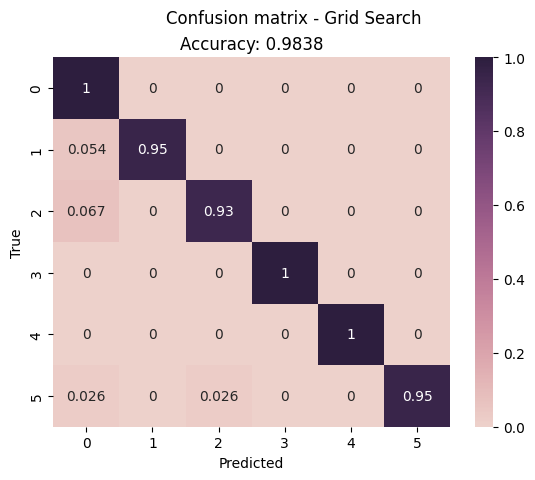

In [26]:
params_svc = {'C':[0.01, 0.1, 1, 10, 100, 1000], 'kernel':['linear']}

t0 = time.time()
clf = GridSearchCV(svm.SVC(), params_svc, cv=5) #ps es una variable global, no se coloca como entrada para reducir al máximo las entradas de la función y hacer menos confusa las iteraciones
tf = time.time() - t0

# GridSearch
clf.fit(X_val, y_val.ravel())
print(clf.best_estimator_)
best_clf = clf.best_estimator_ # Se extraen los mejores hiperparámetros calculados a través de GridSearchCV()

best_clf.fit(X_train, y_train.ravel())

y_pred = best_clf.predict(X_test)

print(f'Tiempo de ejecución: {tf}')
sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
plt.suptitle('Confusion matrix - Grid Search')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### MOEAD

In [27]:
from platypus import Problem, Real
from sklearn.metrics import recall_score, f1_score
from platypus import Problem, Real, Integer

class SVM_linear_optim(Problem):
    def __init__(self):
        super(SVM_linear_optim, self).__init__(1, 1)   # una variable, dos objetivos
        self.types[0] = Real(0, 1000)          # Limite de la variable C
        # self.function = mixed_type

    def evaluate(self, solution):
        x = solution.variables[:]

        model = svm.SVC(kernel='linear', C=x[0])

        X_sub_train, X_sub_val, y_sub_train, y_sub_val = train_test_split(X_val, y_val, test_size=0.2, random_state=42)

        model.fit(X_sub_train, y_sub_train.ravel())

        y_pred = model.predict(X_sub_val)

        acc = accuracy_score(y_sub_val, y_pred)

        rec = recall_score(y_sub_val, y_pred, average = 'macro')

        f1_scr =  f1_score(y_sub_val, y_pred, average='macro')

        solution.objectives[:] = [1 - acc]

problem = SVM_linear_optim

In [28]:
from platypus import NSGAII, CMAES, GDE3, IBEA, MOEAD, NSGAIII
from sklearn.metrics import roc_curve, roc_auc_score

NPOP = 30
NGEN = 200

algorithm = NSGAII(SVM_linear_optim(), population_size=NPOP, divisions_outer=12)

t0 = time.time()
algorithm.run(NPOP*NGEN)
tf = time.time() - t0


print("Final solutions:")
solution = unique(nondominated(algorithm.result))[0]
print(solution)

C = solution.variables[0]
print(f'C: {C}')
print(f'Tiempo de ejecución: {tf}')

Final solutions:
Solution[993.058599398058|0.016129032258064502|0]
C: 993.058599398058
Tiempo de ejecución: 84.2622652053833


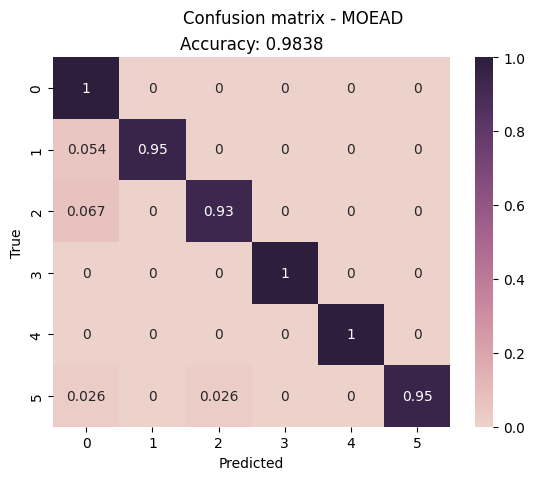

In [29]:
svm_clf = svm.SVC(kernel='linear', C=C)

# Entrenamiento
svm_clf.fit(X_train, y_train.ravel())

# best_clf = clf.best_estimator_ # Se extraen los mejores hiperparámetros calculados a través de GridSearchCV()

y_pred = svm_clf.predict(X_test)

sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
plt.suptitle('Confusion matrix - MOEAD')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### SVM poly

#### Grid Search

SVC(C=100, coef0=1, gamma=10, kernel='poly')
Tiempo de ejecución: 2.5984621047973633


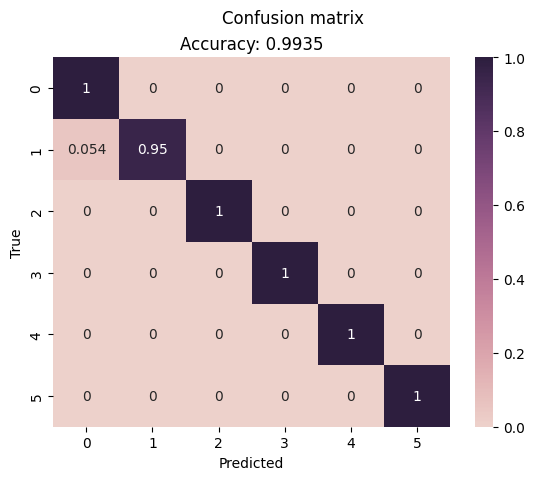

In [30]:
params_svc = {'C':[10, 100, 1000], 'kernel':['poly'], 'degree':[1,3,6], 'gamma':[0.1, 3, 10], 'coef0':[1, 0, -1]}

clf = GridSearchCV(svm.SVC(), params_svc, cv=5) #ps es una variable global, no se coloca como entrada para reducir al máximo las entradas de la función y hacer menos confusa las iteraciones

t0 = time.time()
clf.fit(X_val, y_val.ravel())
tf = time.time() - t0

svm_clf = clf.best_estimator_

# Entrenamiento
svm_clf.fit(X_train, y_train.ravel())

print(svm_clf)

y_pred = svm_clf.predict(X_test)

print(f'Tiempo de ejecución: {tf}')
sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
plt.suptitle('Confusion matrix')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### MOEAD

In [37]:
from platypus import Problem, Real
from sklearn.metrics import recall_score, f1_score
from platypus import Problem, Real, Integer

X_sub_train, X_sub_val, y_sub_train, y_sub_val = train_test_split(X_val, y_val, test_size=0.2, random_state=42)

class SVM_poly_optim(Problem):
    def __init__(self):
        super(SVM_poly_optim, self).__init__(4, 2)   # una variable, dos objetivos
        self.types[0] = Real(0, 1000)          # Limite de la variable C
        self.types[1] = Integer(0, 6)          # Limite de la variable degree
        self.types[2] = Real(0, 10)          # Limite de la variable gamma
        self.types[3] = Real(-10, 10)          # Limite de la variable coef0

    def evaluate(self, solution):
        x = solution.variables[:]

        model = svm.SVC(kernel='poly', C=x[0], degree=x[1], gamma=x[2], coef0=x[3], probability=True)

        model.fit(X_sub_train, y_sub_train.ravel())

        y_pred = model.predict(X_sub_val)

        acc = accuracy_score(y_sub_val, y_pred)
        rec = recall_score(y_sub_val, y_pred, average = 'macro')
        f1_scr =  f1_score(y_sub_val, y_pred, average='macro')

        solution.objectives[:] = [1 - acc, 1 - rec]

problem = SVM_poly_optim

In [38]:
from platypus import NSGAII, CMAES, GDE3, IBEA, MOEAD, NSGAIII
from sklearn.metrics import roc_curve, roc_auc_score

# NPOP = 30
NPOP = 10
# NGEN = 200
NGEN = 10

algorithm = NSGAII(SVM_poly_optim(), population_size=10, divisions_outer=12, variator=CompoundOperator(SBX(), HUX(), PM(), BitFlip()))
# algorithm = NSGAII(SVM_poly_optim(), population_size=10, divisions_outer=12)

t0 = time.time()
algorithm.run(NPOP*NGEN)
tf = time.time() - t0

print("Final solutions:")
solution = unique(nondominated(algorithm.result))[0]
print(solution)

C = solution.variables[0]
degree = int("".join(['1' if b else '0' for b in solution.variables[1]]),2)
gamma = solution.variables[2]
coef0 = solution.variables[3]

print(f'C: {C}')
print(f'degree: {degree}')
print(f'gamma: {gamma}')
print(f'coef0: {coef0}')
print(f'Tiempo de ejecución: {tf}')

Final solutions:
Solution[969.0902685406003,[True, False, True],3.626072029290463,1.8516512251948156|0.0,0.0|0]
C: 969.0902685406003
degree: 5
gamma: 3.626072029290463
coef0: 1.8516512251948156
Tiempo de ejecución: 4.192239046096802


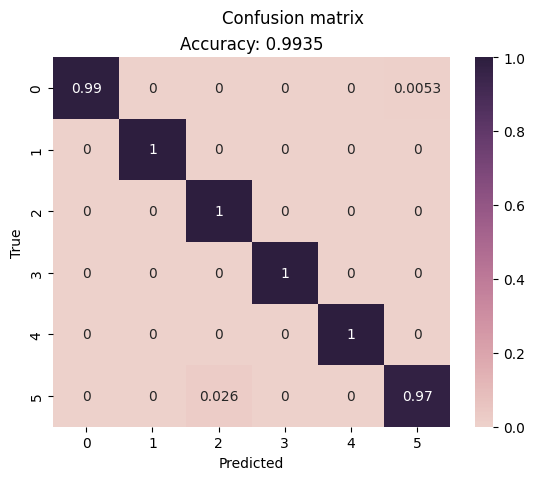

In [39]:
svm_clf = svm.SVC(kernel='poly', C=C, degree=degree, gamma=gamma, coef0=coef0)

# Entrenamiento
svm_clf.fit(X_train, y_train.ravel())

# best_clf = clf.best_estimator_ # Se extraen los mejores hiperparámetros calculados a través de GridSearchCV()

y_pred = svm_clf.predict(X_test)

sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
plt.suptitle('Confusion matrix')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### SVM RBF

#### Grid Search

Tiempo de ejecución: 1.0079538822174072


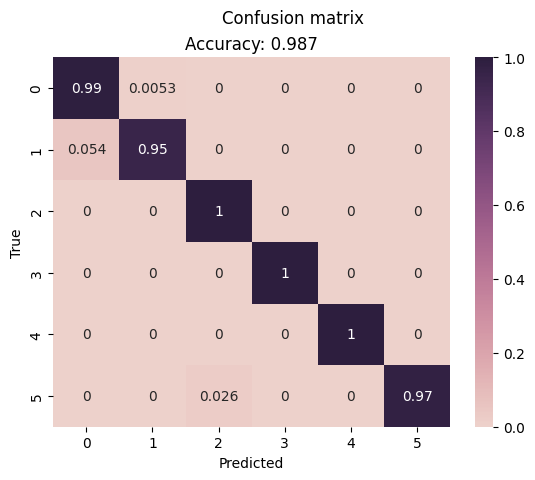

In [40]:
params_svc = {'C':[0.1, 1, 10, 100, 1000], 'kernel':['rbf'], 'gamma':[0.1, 1, 2, 5, 10]}

clf = GridSearchCV(svm.SVC(), params_svc, cv=5) #ps es una variable global, no se coloca como entrada para reducir al máximo las entradas de la función y hacer menos confusa las iteraciones

t0 = time.time()
clf.fit(X_val, y_val.ravel())
tf = time.time() - t0

svm_clf = clf.best_estimator_

# Entrenamiento
svm_clf.fit(X_train, y_train.ravel())

y_pred = svm_clf.predict(X_test)

print(f'Tiempo de ejecución: {tf}')
sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
plt.suptitle('Confusion matrix')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### MOEAD

In [43]:
from platypus import Problem, Real
from sklearn.metrics import recall_score, f1_score

class SVM_RBF_optim(Problem):
    def __init__(self):
        super(SVM_RBF_optim, self).__init__(2, 2)   # 2 variables, 2 objetivos
        self.types[0] = Real(0, 1000)          # Limite de la variable C
        self.types[1] = Real(0, 10)            # Limite de la variable gamma
        # self.types[3] = Real(-10, 10)          # Limite de la variable coef0

    def evaluate(self, solution):
        x = solution.variables[:]

        model = svm.SVC(kernel='rbf', C=x[0], gamma=x[1])

        X_sub_train, X_sub_val, y_sub_train, y_sub_val = train_test_split(X_val, y_val, test_size=0.2, random_state=42)

        model.fit(X_sub_train, y_sub_train.ravel())

        y_pred = model.predict(X_sub_val)

        acc = accuracy_score(y_sub_val, y_pred)
        rec = recall_score(y_sub_val, y_pred, average = 'macro')
        # f1_scr =  f1_score(y_sub_val, y_pred, average='macro')

        solution.objectives[:] = [1 - acc, 1 - rec]

problem = SVM_RBF_optim

In [48]:
from platypus import NSGAII, CMAES, GDE3, IBEA, MOEAD, NSGAIII
from sklearn.metrics import roc_curve, roc_auc_score

NPOP = 10
NGEN = 10

algorithm = NSGAII(problem(), population_size=10)#, divisions_outer=12)

t0 = time.time()
algorithm.run(NPOP*NGEN)
tf = time.time() - t0

In [49]:
idx = random.randint(0, len(algorithm.result)-1)

C = algorithm.result[idx].variables[0]
gamma = algorithm.result[idx].variables[1]

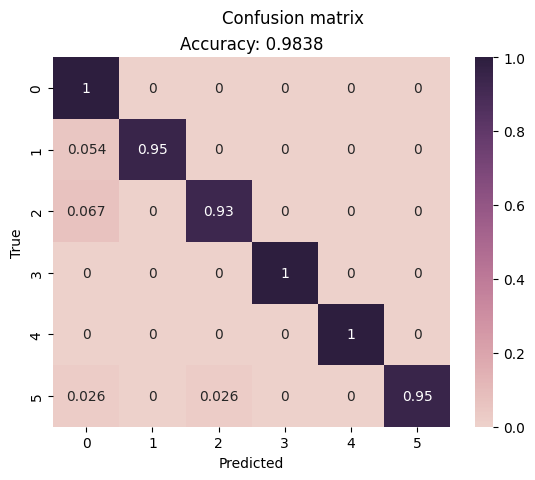

In [51]:
svm_clf = svm.SVC(kernel='rbf', C=C, gamma=gamma)

# Entrenamiento
best_clf.fit(X_train, y_train.ravel())

y_pred = best_clf.predict(X_test)

sns.heatmap(np.round(confusion_matrix(y_test, y_pred, normalize='true'), decimals=6), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
plt.suptitle('Confusion matrix')
plt.title(f'Accuracy: {round(accuracy_score(y_test, y_pred),4)}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Programación genética V5: Optimización multiobjetivo ANN

In [ ]:
import torch
import torch.nn as nn
!pip install pytorch-ignite
!pip install early-stopping-pytorch
from early_stopping_pytorch import EarlyStopping
import torch.nn.functional as F

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.8/343.8 kB 13.0 MB/s eta 0:00:00


In [ ]:
class EarlyStoppingCustom:
    def __init__(self, patience=15, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float("inf")

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Guarda el modelo si ha habido mejora'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), 'best_model.pt')
        self.val_loss_min = val_loss

In [ ]:
# def train_model(model, patience, n_epochs, optimizer):
def train_model_generic(model, patience, n_epochs, optimizer, dataloader_tr, dataloader_vl):

  # Listas para guardar valores de loss por cada batch y por cada época
  train_losses = []
  valid_losses = []
  # Listas para guardar los pesos de cada batch, depende del tamaño de cada batch, esto es importante porque el último batch siempre es más pequeño
  batch_weights_train = []
  batch_weights_val = []
  # Listas para guardar la pérdida promedio de cada época
  avg_train_losses = []
  avg_valid_losses = []
  #Bandera para guardar el modelo una única vez bajo el nombre best_model.pt
  model_saved = False

  # initialize the early_stopping object
  early_stopping = EarlyStoppingCustom(patience=patience, verbose=False)

  start = time.time()
  for epoch in range(1, n_epochs + 1):
    # Entrenamiento
    model.train() # prep model for training

    for batch in dataloader_train:
      inputs = batch["features"].to(device)
      targets = batch["labels"].to(device).squeeze(1) # Correponde a las clases de los datos
      # Igualar a 0 los gradientes de todas las variables optimizadas
      optimizer.zero_grad()
      # Predicciones
      output = model(inputs)
      # Cálculo de la pérdida
      loss = criterion(output, targets)
      # backward pass
      loss.backward()
      # Actualización de parámetros de la red (mediante Adam)
      optimizer.step()
      train_losses.append(loss.item())
      batch_weights_train.append(targets.size(0))

    # Validación
    model.eval()
    with torch.no_grad():
      for batch in dataloader_val:
        inputs = batch["features"].to(device)
        targets = batch["labels"].to(device).squeeze(1)

        # Predicciones
        output = model(inputs)
        # Cálculo de la pérdida
        loss = criterion(output, targets)
        # Loss de validación de un solo batch
        valid_losses.append(loss.item())
        batch_weights_val.append(targets.size(0))

    train_loss = np.average(np.array(train_losses), weights = np.array(batch_weights_train))
    valid_loss = np.average(np.array(valid_losses), weights = np.array(batch_weights_val))

    # Se calcula el promedio del loss de todas las épocas
    avg_train_losses.append(train_loss)
    avg_valid_losses.append(valid_loss)

    epoch_len = len(str(n_epochs))

    print_msg = (f'[{epoch:>{epoch_len}}/{n_epochs:>{epoch_len}}] ' + f'train_loss: {train_loss:.6f} ' + f'valid_loss: {valid_loss:.6f}')
    # print(print_msg)

    # Se reinician las listas para guardar los valores de loss y los pesos de cada batch de la siguiente época
    train_losses = []
    valid_losses = []
    batch_weights_train = []
    batch_weights_val = []

    early_stopping(valid_loss, model)

    if early_stopping.early_stop and not model_saved:
        best_epoch = epoch - patience
        val_loss_min = avg_valid_losses[best_epoch - 1]
        print('Early stopping at -------------------------------------------------->',best_epoch)
        torch.save(model.state_dict(), 'best_model.pt') # En la línea a continuación se guarda el último checkpoint guardado por earlystopping, despues no se vuelve a guardar bajo este mismo nombre, de manera que este es el mejor modelo basado en patience early stopping
        model_saved = True
        training_time = time.time() - start # Se calcula aqui porque el modelo puede terminar de entrenarse antes de las 1000 épocas, por lo tanto, no sería correcto calcularlo al final, ya que el loss de validación y entrenamiento que se sigue calculando es para ver que tanto diverge el de validación en comparación al de entrenamiento para la totalidad de las épocas

    torch.cuda.empty_cache()
    torch.cuda.synchronize()

  # Cargar el mejor modelo guardado con el criterio de patience early stopping
  model.load_state_dict(torch.load('best_model.pt', weights_only=True))
  print(f"Mejor modelo en la época {best_epoch} con loss de validación = {val_loss_min:.6f}")

  return  model, avg_train_losses, avg_valid_losses, training_time, best_epoch, dataloader_tr, dataloader_vl

In [ ]:
def results_ANN(model, train_loss_values, valid_loss_values, t_time, best_ep, dataloader_tr, dataloader_vl):

    print_graphs = False

    # Obtener el nombre del modelo
    nombre_red = model.name  # Devuelve: 'MiRed'
    epochs = np.linspace(1, len(train_loss_values), len(train_loss_values))
    loss_valid_best_epoch = valid_loss_values[best_ep - 1]
    loss_train_best_epoch = train_loss_values[best_ep - 1]

    if print_graphs:
      os.makedirs(ruta, exist_ok=True)
      # Gráfico de loss de validación y entrenamiento
      prop = 0.95
      figsize = (prop*6.4, 0.95*4.8)
      plt.figure(figsize = figsize)
      plt.plot(epochs, train_loss_values, lw=1, color='blue', label='Train')
      plt.plot(epochs, valid_loss_values, lw=1, color='red', label='Validation')
      plt.axvline(x=best_ep, color='black', ls='--', lw=1)#, label='Best epoch')
      plt.text(x=best_ep, y=0.8, s=f'Valid Loss: {loss_valid_best_epoch:.4f}\nTrain Loss: {loss_train_best_epoch:.4f}\nBest epoch: {best_ep}', fontsize=8, fontfamily='sans-serif', verticalalignment='top', horizontalalignment='left', bbox=dict(facecolor='yellow', boxstyle='round', alpha=1))
      plt.text(x=0, y=0.02, s=f'Tiempo de entrenamiento: {t_time:.2f} [s]', fontsize=8, fontfamily='sans-serif', verticalalignment='bottom', horizontalalignment='left', bbox=dict(facecolor='yellow', boxstyle='round', alpha=1))
      plt.xlabel("Epoch")
      plt.ylabel("Loss")
      plt.ylim(-0.05,1)
      if nombre_red[-6] != '1':
        plt.title(f'Loss de entrenamiento y validación, ANN de\n{nombre_red[-6]} capas ocultas de {nombre_red[6:-8]} neuronas y función de activación {nombre_red[-4:]}')
      else:
        plt.title(f'Loss de entrenamiento y validación, ANN de\ncapa oculta de {nombre_red[6:-8]} neuronas y función de activación {nombre_red[-4:]}')
      plt.grid()
      plt.legend()
      plt.savefig(f'{ruta}loss_epoch{nombre_red[5:]}.svg')
    else:
      pass

    # Matriz de confusión normalizada - Conjunto de entrenamiento
    model.eval()
    all_preds = []
    all_labels = []
    correct_total = 0
    total = 0

    with torch.no_grad():
      for batch in dataloader_train:
          inputs = batch["features"].to(device)
          targets = batch["labels"].to(device).squeeze(1)

          # Predicciones
          output = model(inputs)
          # output = torch.softmax(output, dim=1)  # predictions.shape = [batch_size]

          # Acumula las predicciones y etiquetas
          out = torch.argmax(output, dim=1)  # Forma [batch_size]
          all_preds.append(out.cpu().numpy())
          all_labels.append(targets.cpu().numpy())

          # Contar aciertos en este batch
          predicted_classes = torch.argmax(output, dim=1)  # Forma [batch_size]
          correct = (predicted_classes == targets).sum().item()
          correct_total += correct # Contador de predicciones correctas
          total += targets.size(0) #Tamaño de cada batch

    # Concatenar todas las predicciones y etiquetas
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Precisión
    accuracy_tr = correct_total / total

    if print_graphs:
      # Mostrar la matriz de confusión
      disp = ConfusionMatrixDisplay(np.round(confusion_matrix(all_labels, all_preds, normalize='true'), decimals=4))#, display_labels=labels_train)
      disp.plot(cmap='RdPu')

      if nombre_red[-6] != '1':
        plt.suptitle(f'Matriz de confusión normalizada del conjunto de entrenamiento, ANN de\n{nombre_red[-6]} capas ocultas de {nombre_red[6:-8]} neuronas y función de activación {nombre_red[-4:]}', x=0.5, y=1.01, fontsize=11)
      else:
        plt.suptitle(f'Matriz de confusión normalizada del conjunto de entrenamiento, ANN de\ncapa oculta de {nombre_red[6:-8]} neuronas y función de activación {nombre_red[-4:]}', x=0.5, y=1.01, fontsize=11)

      plt.title(f'Accuracy = {accuracy_tr:.4f}', fontsize = 10)
      plt.savefig(f'{ruta}conf_mat_train{nombre_red[5:]}.svg', bbox_inches='tight')
    else:
      pass


    # Matriz de confusión normalizada - Conjunto de validación
    all_preds = []
    all_labels = []
    correct_total = 0
    total = 0

    with torch.no_grad():

      for batch in dataloader_val:
          inputs = batch["features"].to(device)
          targets = batch["labels"].to(device).squeeze(1)

          # Predicciones
          output = model(inputs)
          # output = torch.softmax(output, dim=1)  # predictions.shape = [batch_size]

          # Acumula las predicciones y etiquetas
          out = torch.argmax(output, dim=1)  # Forma [batch_size]
          all_preds.append(out.cpu().numpy())
          all_labels.append(targets.cpu().numpy())

          # Contar aciertos en este batch
          predicted_classes = torch.argmax(output, dim=1)  # Forma [batch_size]
          correct = (predicted_classes == targets).sum().item()
          correct_total += correct # Contador de predicciones correctas
          total += targets.size(0) #Tamaño de cada batch

    # Concatenar todas las predicciones y etiquetas
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Precisión
    accuracy_vl = correct_total / total
    # print(f"Accuracy promedio conjunto de entrenamiento: {accuracy:.4f}")

    if print_graphs:
      # Mostrar la matriz de confusión
      disp = ConfusionMatrixDisplay(np.round(confusion_matrix(all_labels, all_preds, normalize='true'), decimals=4))#, display_labels=labels_train)
      disp.plot(cmap='RdPu')
      if nombre_red[-6] != '1':
        plt.suptitle(f'Matriz de confusión normalizada del conjunto de validación, ANN de\n{nombre_red[-6]} capas ocultas de {nombre_red[6:-8]} neuronas y función de activación {nombre_red[-4:]}', x=0.5, y=1.01, fontsize=11)
      else:
        plt.suptitle(f'Matriz de confusión normalizada del conjunto de validación, ANN de\ncapa oculta de {nombre_red[6:-8]} neuronas y función de activación {nombre_red[-4:]}', x=0.5, y=1.01, fontsize=11)
      plt.title(f'Accuracy = {accuracy_vl:.4f}', fontsize = 10)
      plt.savefig(f'{ruta}conf_mat_val{nombre_red[5:]}.svg', bbox_inches='tight')
      plt.show()
    else:
      pass

    return accuracy_vl

In [ ]:
device = torch.device('cuda')
criterion = nn.CrossEntropyLoss()

In [ ]:
# Crear datasets
feats_train = X_train.astype(np.float32)
labels_train = y_train.astype(int)
dataset_train = [ {"features":feats_train[i,:], "labels":labels_train[i]} for i in range(feats_train.shape[0]) ]

feats_val = X_val.astype(np.float32)
labels_val = y_val.astype(int)
dataset_val = [ {"features":feats_val[i,:], "labels":labels_val[i]} for i in range(feats_val.shape[0]) ]

feats_test = X_test.astype(np.float32)
labels_test = y_test.astype(int)
dataset_test = [ {"features":feats_test[i,:], "labels":labels_test[i]} for i in range(feats_test.shape[0]) ]

In [ ]:
# Crear dataloaders
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=256, shuffle=True, num_workers=0, drop_last=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=256, shuffle=True, num_workers=0, drop_last=True)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=256, shuffle=True, num_workers=0, drop_last=True)

In [ ]:
N_FEATURES = len(X.keys())
N_CLASSES = 15 #len(y['col_damaged'].unique())

print(N_CLASSES)

15


In [ ]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

Early stopping at --------------------------------------------------> 349
Mejor modelo en la época 349 con loss de validación = 0.148673


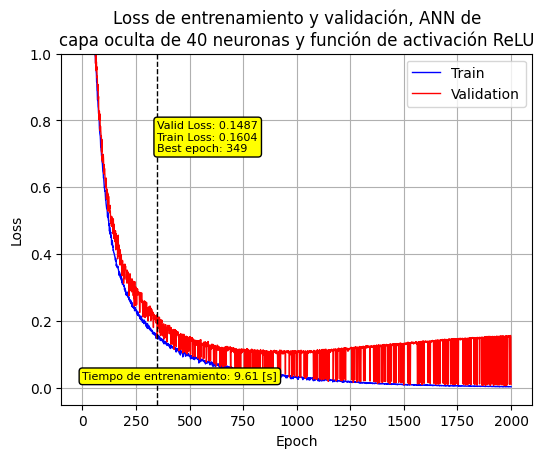

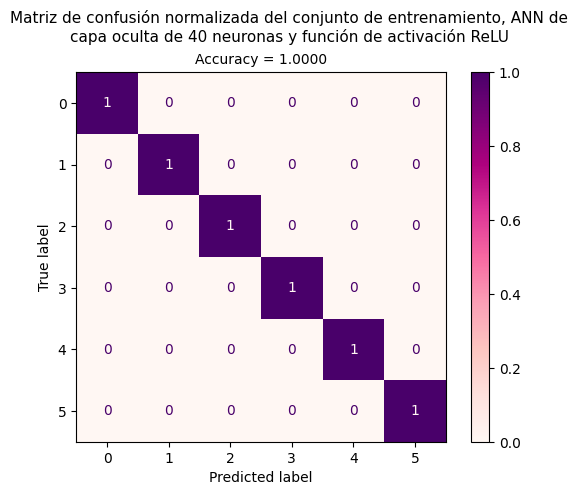

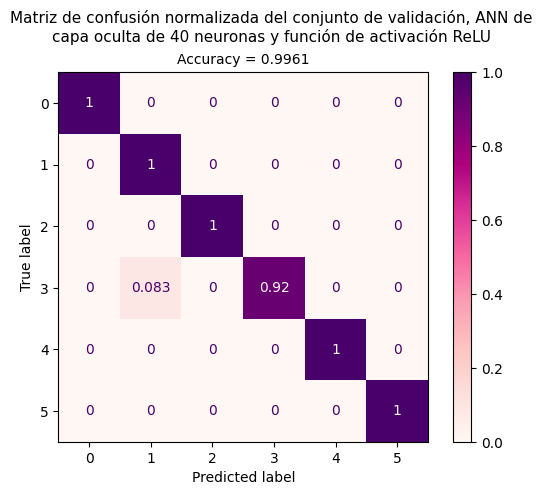

In [ ]:
neurons_per_layer = 40
N_CLASSES = 15

model = nn.Sequential(nn.Linear(N_FEATURES, neurons_per_layer), nn.ReLU(), nn.Linear(neurons_per_layer, N_CLASSES)).to(device)
model.name = f'model_{neurons_per_layer}co1_ReLU'  # Se agrega el nombre como atributo
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
ruta = '/content/drive/MyDrive/Proyecto_CE/graphs/'
acc = results_ANN(*train_model_generic(model=model, patience=30, n_epochs=2000, optimizer=optimizer, dataloader_tr=dataloader_train, dataloader_vl=dataloader_val))

In [ ]:
from platypus import Problem, Real
from sklearn.metrics import recall_score, f1_score
from platypus import Problem, Real, Integer

class ANN_optim(Problem):
    def __init__(self):
        super(ANN_optim, self).__init__(1, 1)   # una variable, dos objetivos
        self.types[0] = Integer(30,40)  # ESTA es la que realmente estás usando

    def evaluate(self, solution):
        x = solution.variables[:]
        neurons_per_layer = x[0]

        model = nn.Sequential(nn.Linear(N_FEATURES, neurons_per_layer), nn.ReLU(), nn.Linear(neurons_per_layer, N_CLASSES)).to(device)
        model.name = f'model_{neurons_per_layer}co_ReLU'  # Se agrega el nombre como atributo
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        acc = results_ANN(*train_model_generic(model=model, patience=10, n_epochs=300, optimizer=optimizer, dataloader_tr=dataloader_train, dataloader_vl=dataloader_val))

        solution.objectives[:] = [1 - acc]

problem = ANN_optim

In [ ]:
algorithm = NSGAII(ANN_optim(), population_size=10)#, divisions_outer=12)
algorithm.run(10)

Early stopping at --------------------------------------------------> 162
Mejor modelo en la época 162 con loss de validación = 0.485633
Early stopping at --------------------------------------------------> 184
Mejor modelo en la época 184 con loss de validación = 0.379411
Early stopping at --------------------------------------------------> 156
Mejor modelo en la época 156 con loss de validación = 0.454582
Early stopping at --------------------------------------------------> 201
Mejor modelo en la época 201 con loss de validación = 0.305853
Early stopping at --------------------------------------------------> 212
Mejor modelo en la época 212 con loss de validación = 0.276018
Early stopping at --------------------------------------------------> 182
Mejor modelo en la época 182 con loss de validación = 0.341477
Early stopping at --------------------------------------------------> 157
Mejor modelo en la época 157 con loss de validación = 0.357263
Early stopping at -----------------------

In [ ]:
algorithm.result

[Solution[[False, False, False, False]|0.06640625|0],
 Solution[[False, False, False, False]|0.0625|0],
 Solution[[False, True, True, False]|0.0546875|0],
 Solution[[False, True, True, False]|0.0390625|0],
 Solution[[True, True, False, True]|0.02734375|0],
 Solution[[True, True, False, True]|0.03515625|0],
 Solution[[True, True, True, True]|0.03125|0],
 Solution[[False, False, True, True]|0.0390625|0],
 Solution[[False, False, True, True]|0.046875|0],
 Solution[[True, True, False, False]|0.03515625|0]]

In [ ]:
print("Final solutions:")
solution = unique(nondominated(algorithm.result))[0]
print(solution)

bits = ''.join('1' if b else '0' for b in solution.variables[0])
n_co = int(bits, 2)

n_co = bits_to_range(solution.variables[0])

print(bits, n_co)

Final solutions:


IndexError: list index out of range

In [ ]:
algorithm.result#[idx].variables[0]

[Solution[[True, True]|0.02734375|0], Solution[[True, True]|0.046875|0]]

# Gráficos

In [ ]:
ansys_data = X1

In [ ]:
X1
y1['col_damaged'].unique()

array([1])

In [ ]:
X

,delta_Tc_1,delta_Tc_2,delta_Tf_1,delta_Tf_2,delta_Tf_3,delta_Vf_1,delta_Vf_2,delta_Vf_3
0,-0.203803,0.005962,-0.203803,0.005962,-0.750730,-0.203803,0.005962,-0.750730
1,0.651928,-0.355126,0.651928,-0.355126,-0.738387,0.651928,-0.355126,-0.738387
2,0.150144,0.674343,0.150144,0.674343,-1.270955,0.150144,0.674343,-1.270955
3,-0.327429,-0.070144,-0.327429,-0.070144,-1.075340,-0.327429,-0.070144,-1.075340
4,0.992080,-0.624025,0.992080,-0.624025,-1.069532,0.992080,-0.624025,-1.069532
...,...,...,...,...,...,...,...,...
1751,0.018907,0.016766,0.018907,0.016766,-0.424205,0.018907,0.016766,-0.424205
1752,0.018316,0.016484,0.018316,0.016484,-0.417805,0.018316,0.016484,-0.417805
1753,0.016609,0.017168,0.016609,0.017168,-0.411570,0.016609,0.017168,-0.411570
1754,0.017034,0.016223,0.017034,0.016223,-0.405631,0.017034,0.016223,-0.405631


In [ ]:
# ansys_data['col_damaged'].unique()

array([1])

ValueError: x and y must have same first dimension, but have shapes (7,) and (0,)

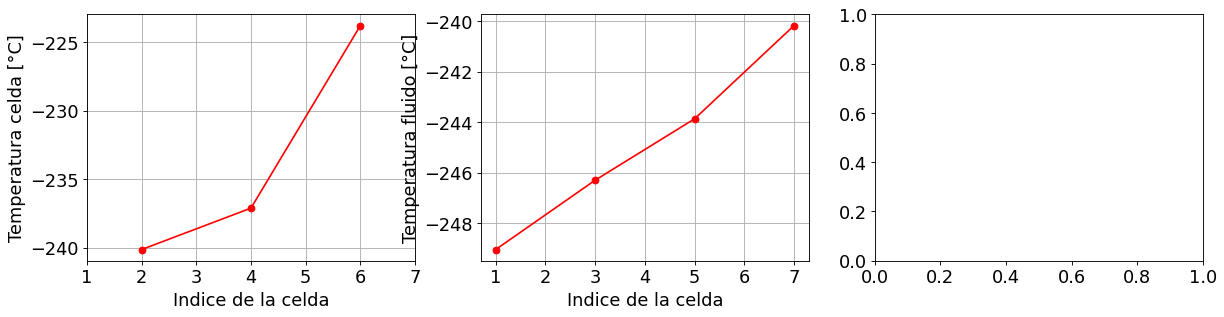

In [ ]:
# Figura para agrupar los gráficos
plt.rc('font', size=16) # Sets the default font size to 12 points
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18,4), dpi=80)

# Índice random
idx = random.randint(0, len(ansys_data))
# print(ansys_data.filter(like='col_').iloc[idx])
# print(ansys_data['col_damaged'].iloc[idx])
# print(idx)

# Temperatura del fluido
tf_data = ansys_data.filter(like='Tf')
tf_data = tf_data.iloc[idx] - 273.15

# Temperatura de la celda
tc_data = ansys_data.filter(like='Tc0') #- 273.15
tc_data = tc_data.iloc[idx] - 273.15

# Calor generado por celda
cc_data = ansys_data.filter(like='q')
cc_data = cc_data.iloc[idx]

col_fluido = np.linspace(1, 2*len(tf_data)-1, len(tf_data)).astype(int)
col_celda = np.linspace(2, 2*len(tc_data), len(tc_data)).astype(int)
cols_all_idx = np.linspace(1, col_fluido[-1], col_fluido[-1]).astype(int)

ax[0].plot(col_celda, tc_data, 'ro-')
ax[0].set_ylabel('Temperatura celda [°C]')
ax[0].set_xlabel('Indice de la celda')
ax[0].set_xticks(cols_all_idx)
ax[0].grid()

ax[1].plot(col_fluido, tf_data, 'ro-')
ax[1].set_ylabel('Temperatura fluido [°C]')
ax[1].set_xlabel('Indice de la celda')
ax[1].set_xticks(cols_all_idx)
ax[1].grid()

ax[2].plot(cols_all_idx, cc_data, 'ro-')
ax[2].set_ylabel('Calor generado [W m^-3]')
ax[2].set_xlabel('Indice de la celda')
ax[2].set_xticks(cols_all_idx)
ax[2].grid()

plt.tight_layout()
plt.show()

Le pasamos al algoritmo genético las temperaturas

# Filtrado parcial, solo para mostrar que hay datos con más celdas dañadas

In [ ]:
def data_filter_of_NaNs(data):
    # Lista para guardar las filas que hay que borrar
    rows_to_drop = []

    # Ciclos par recorrer toda la dat y borrar aquellas filas con NaNs
    for simulation in range(len(data)):
        for variable in range(1,len(data.keys())):
            # Verificar si el valor es NaN
            if np.isnan(data.iloc[simulation, variable]):
                rows_to_drop.append(simulation)
                break # El break se usa para salir del ciclo for variable y guardar solo un dato de la columna que se va a borrar

    # Borrado de las filas
    return data.drop(rows_to_drop)


def labeler_of_data_with_heat_data(data):
    # Datos de calor
    heat_data = data.filter(like='q')

    # Nombres de las columnas etiquetadas
    columns_idxs = np.linspace(1, len(heat_data.keys()), len(heat_data.keys())).astype(int)
    columns_idxs = [f"col_{i+1}" for i in range(len(heat_data.columns))]

    # Array con ceros para despues reemplazar con los labels
    base_dataframe_for_label_with_heat_data = pd.DataFrame(np.zeros((len(heat_data) ,len(heat_data.keys()))), columns=columns_idxs)

    for simulation in range(len(heat_data)):
        damaged_cell_idx_column_list = [] # Ubicación de las celdas desgastadas en una simulación, pueden ser más de una
        for heat_value in range(len(heat_data.keys())-1):

            if heat_data.iloc[simulation, heat_value] > heat_data.iloc[simulation, heat_value+1]:
                damaged_cell_idx_column_list.append(1)

            else:
                damaged_cell_idx_column_list.append(0)
        damaged_cell_idx_column_list.append(0) # Se asigna el último 0 solo para que queden 7 elementos en la lista de ubicación de daño

        base_dataframe_for_label_with_heat_data.iloc[simulation] = np.array(damaged_cell_idx_column_list)

        # Mostrar todas las filas y los labels
        # print(simulation,' : ',damaged_cell_idx_column_list) # Se suma uno para que el valor de las celdas no dañadas sea 0

    # Concatenación de la data con los labels
    return pd.concat([data, base_dataframe_for_label_with_heat_data], axis=1)


def filter_from_several_columns_to_one_column_label(data): # Esta función lo que hace es filtrar los datos que tienen más de una columna dañada eliminando aquellas que tienen más de una columna dañada
    # Lista para guardar las filas que hay que borrar
    rows_to_drop = []
    labels_data = data.filter(like='col_')

    # Ciclos par recorrer toda la data y borrar aquellas filas donde hay más de una columna con labels = 1
    for simulation in range(len(data)):
        if labels_data.iloc[simulation].sum() > 1 or labels_data.iloc[simulation].sum() == 0:
            rows_to_drop.append(simulation)

    # Borrado de las filas
    return data.drop(rows_to_drop)


def filter_from_binary_labels_to_column_idx(data):
    labels_data = data.filter(like='col_')
    damaged_cell_idx_column_list = []

    for simulation in range(len(labels_data)):
        fila = labels_data.iloc[simulation].to_numpy()      # convierte fila a array
        idx = np.where(fila == 1)[0]                      # posiciones donde hay 1

        if len(idx) > 0:
            damaged_cell_idx_column_list.append(idx[0]+1)  # toma la primera posición con 1
        else:
            damaged_cell_idx_column_list.append(0)    # o -1 si quieres marcar "sin daño"

    data['col_damaged'] = damaged_cell_idx_column_list
    return data


def data_extractor_from_ansys_raw_data(csv_name):
    # Path y nombre del csv
    file_name = os.path.join(ansys_data_path, csv_name)

    # Extracción de los nombre de las columnas
    keys = pd.read_csv(file_name, sep=',', skipinitialspace=False, skiprows=3, skipfooter=0, engine='python')

    # Variables y sus unidades respectivas
    names_n_units_of_data = [name[5:] if keys.columns.get_loc(name)<10
                             else name[6:] for name in keys.keys()]
    # La data
    data = pd.read_csv(file_name, sep=',', skipinitialspace=False, header=6, skipfooter=0, names = names_n_units_of_data, engine='python')

    # Filtrado de NaNs
    data = data_filter_of_NaNs(data)

    # Generación de etiquetas
    # data = labeler_of_data_with_heat_data(data)

    # Filtrado de datos a una única columna dañada
    # data = filter_from_several_columns_to_one_column_label(data)

    # Transformación de labels [0, 1, 0, ... , 0] a ubicación de la columna
    # data = filter_from_binary_labels_to_column_idx(data)

    return data

In [ ]:
# cells_53_soh82_data = data_extractor_from_ansys_raw_data(csv_name='out53_soh82.csv')
cells_25_soh45_1_data = data_extractor_from_ansys_raw_data(csv_name='out25_soh45_1.csv')
ansys_data = cells_25_soh45_1_data

NameError: name 'ansys_data_path' is not defined

In [ ]:
ansys_data = data_extractor_from_ansys_raw_data(csv_name='out25_soh45_1.csv')
# ansys_data = data_extractor_from_ansys_raw_data(csv_name='out53_soh45.csv')

Series([], Name: 41, dtype: float64)


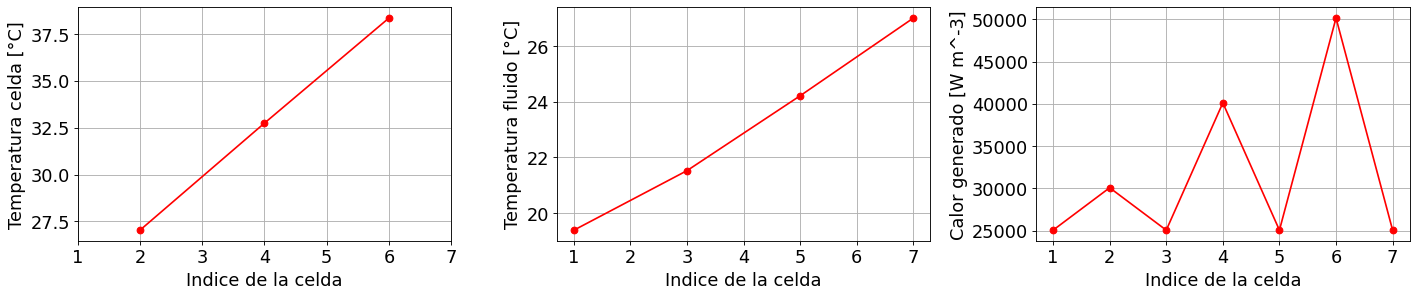

In [ ]:
# Figura para agrupar los gráficos
plt.rc('font', size=16) # Sets the default font size to 12 points
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18,4), dpi=80)

# Índice random
idx = random.randint(0, len(ansys_data))
print(ansys_data.filter(like='col_').iloc[idx])
# print(ansys_data['col_damaged'].iloc[idx])
# print(idx)

# Temperatura del fluido
tf_data = ansys_data.filter(like='Tf')
tf_data = tf_data.iloc[idx] - 273.15

# Temperatura de la celda
tc_data = ansys_data.filter(like='Tc0') #- 273.15
tc_data = tc_data.iloc[idx] - 273.15

# Calor generado por celda
cc_data = ansys_data.filter(like='q')
cc_data = cc_data.iloc[idx]

col_fluido = np.linspace(1, 2*len(tf_data)-1, len(tf_data)).astype(int)
col_celda = np.linspace(2, 2*len(tc_data), len(tc_data)).astype(int)
cols_all_idx = np.linspace(1, col_fluido[-1], col_fluido[-1]).astype(int)

ax[0].plot(col_celda, tc_data, 'ro-')
ax[0].set_ylabel('Temperatura celda [°C]')
ax[0].set_xlabel('Indice de la celda')
ax[0].set_xticks(cols_all_idx)
ax[0].grid()

ax[1].plot(col_fluido, tf_data, 'ro-')
ax[1].set_ylabel('Temperatura fluido [°C]')
ax[1].set_xlabel('Indice de la celda')
ax[1].set_xticks(cols_all_idx)
ax[1].grid()

ax[2].plot(cols_all_idx, cc_data, 'ro-')
ax[2].set_ylabel('Calor generado [W m^-3]')
ax[2].set_xlabel('Indice de la celda')
ax[2].set_xticks(cols_all_idx)
ax[2].grid()

plt.tight_layout()
plt.show()

Le pasamos al algoritmo genético las temperaturas

In [ ]:
# Temperatura del fluido
tf_data = ansys_data.filter(like='Tf') - 273.15
# Temperatura de la celda
tc_data = ansys_data.filter(like='Tc0') - 273.15
# labels
labels = ansys_data.filter(like='col_damaged')

display(pd.concat([tc_data, tf_data, labels], axis=1))

,Tc01 [K],Tc02 [K],Tc03 [K],Tc04 [K],Tc05 [K],Tc06 [K],Tc07 [K],Tf01 [K],Tf02 [K],Tf03 [K],Tf04 [K],Tf05 [K],Tf06 [K],Tf07 [K],Tf08 [K],col_damaged
1,44.205,38.094,44.378,51.793,59.009,66.090,73.036,13.765,25.299,32.669,40.084,47.388,54.742,61.904,68.480,2
2,93.193,74.695,88.316,104.253,120.111,136.357,152.962,19.265,44.518,60.030,76.477,93.204,109.547,125.523,129.756,2
3,26.813,23.154,25.250,27.941,30.844,33.691,36.547,11.374,16.581,18.974,21.792,24.741,27.720,30.691,33.818,2
4,22.462,19.308,20.899,22.901,24.897,26.904,28.828,11.168,14.427,16.536,18.561,20.575,22.560,24.627,26.561,2
5,14.042,12.904,13.326,13.870,14.455,15.056,15.644,10.326,11.296,11.848,12.424,13.003,13.598,14.183,14.676,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,34.384,34.843,35.458,35.938,36.489,36.972,43.996,30.435,30.968,31.438,31.927,32.419,32.932,33.448,34.278,14
1247,48.317,52.882,55.490,57.777,60.743,63.721,93.530,33.835,38.585,42.009,44.152,46.487,49.436,52.499,59.166,14
1248,30.394,30.460,30.497,30.555,30.617,30.678,31.324,30.063,30.136,30.189,30.235,30.290,30.350,30.407,30.525,14
1500,30.896,31.029,31.102,31.218,31.385,32.875,33.244,30.127,30.274,30.376,30.489,30.610,30.741,31.039,31.233,0


# Borrador

In [ ]:
# Limpieza de los nombres para quitar 'PX - '
# cells_25_soh45_1_keys_only_name_n_units = [name[5:] if cells_25_soh45_1_keys.columns.get_loc(name)<10 and cells_25_soh45_1_keys.columns.get_loc(name)!=0 #Se añade una condición extra para mantener el
#                                            else name[6:] if cells_25_soh45_1_keys.columns.get_loc(name)>=10
#                                            else name[0] for name in cells_25_soh45_1_keys.keys()]